# Exploratory Data Analysis
Business Rehearsal Outcome Predictor · Spring 2026

Overview of the engineered training dataset: feature distributions, target shapes, and category breakdowns.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})

TARGETS = ['label_inventory_delta', 'label_cashflow_delta', 'label_order_velocity_delta']
META    = ['branch_id', 'business_id', 'category', 'branch_type', 'committed_at']
DROP    = META + TARGETS

In [2]:
df = pd.read_csv('data/processed/training_data.csv', parse_dates=['committed_at'])
feat_cols = [c for c in df.columns if c not in DROP]

print(f"Rows: {len(df):,}  |  Features: {len(feat_cols)}  |  Targets: {len(TARGETS)}")
print(f"Date range: {df['committed_at'].min().date()} → {df['committed_at'].max().date()}")
print(f"Businesses: {df['business_id'].nunique()}  |  Branch types: {df['branch_type'].nunique()}")
df[META + TARGETS].head()

Rows: 2,100  |  Features: 73  |  Targets: 3
Date range: 2025-11-30 → 2026-08-17
Businesses: 150  |  Branch types: 10


,branch_id,business_id,category,branch_type,committed_at,label_inventory_delta,label_cashflow_delta,label_order_velocity_delta
0,4243c729-0768-40f3-83c4-73cd0aabc9e7,721a9a33-74e4-4436-a723-41dd03a717fa,retail,price_decrease,2026-06-27,-3.32,-44.39,6.47
1,b8b673a4-1fcf-43fc-b800-7efc744dff33,85cafa58-94ab-42cc-9dd8-9e8b0ba83d49,retail,price_decrease,2026-05-13,-7.24,68.03,12.32
2,53ba7a8a-d4e1-4cf9-953a-2708da195ef7,73479d8f-f74f-4843-ba96-243fd56c906a,retail,bulk_restock,2026-02-24,194.34,-6890.94,6.20
3,fa10fc41-ad23-42c3-860f-af11565efa5b,73479d8f-f74f-4843-ba96-243fd56c906a,retail,price_decrease,2026-03-15,-4.92,-817.25,9.98
4,a359b573-891c-4ad7-903d-d21fb7a7e76a,9090dc5d-4765-47ec-a40b-cfa025064f4c,retail,bulk_restock,2026-07-28,237.05,-13412.93,5.17


## Target distributions
Each target is a delta — positive = increase, negative = decrease — over the 14-day outcome window.

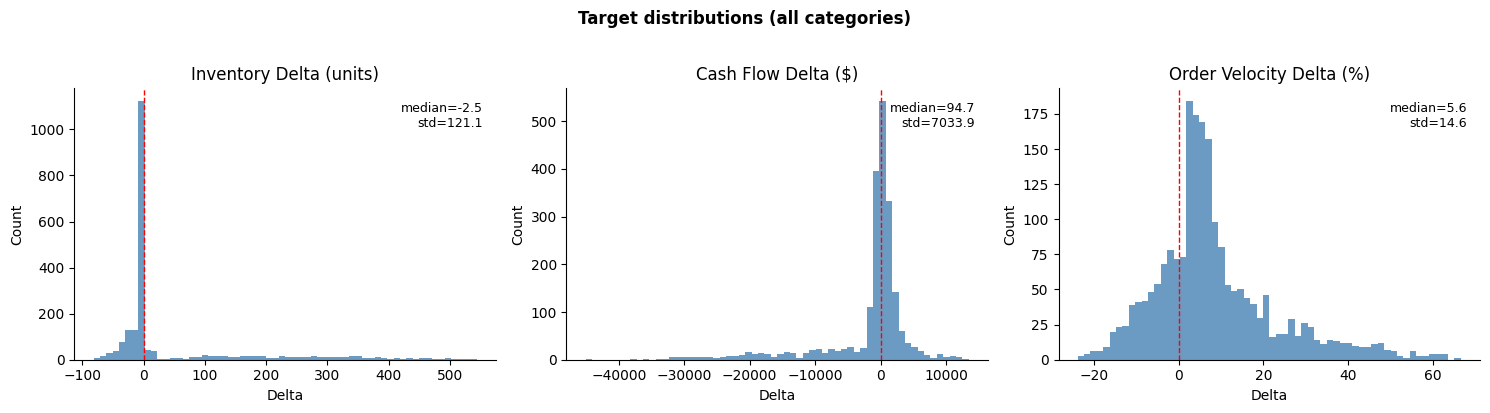

In [3]:
labels = {
    'label_inventory_delta':      'Inventory Delta (units)',
    'label_cashflow_delta':       'Cash Flow Delta ($)',
    'label_order_velocity_delta': 'Order Velocity Delta (%)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGETS):
    vals = df[target]
    ax.hist(vals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='red', lw=1, linestyle='--')
    ax.set_title(labels[target])
    ax.set_xlabel('Delta')
    ax.set_ylabel('Count')
    ax.annotate(f'median={vals.median():.1f}\nstd={vals.std():.1f}',
                xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=9)
plt.suptitle('Target distributions (all categories)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## Category & branch type breakdown

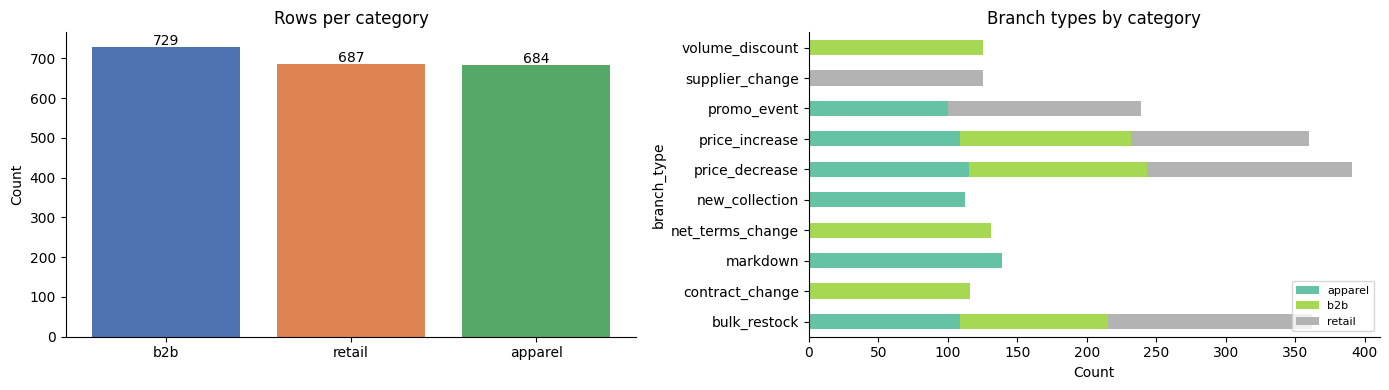

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rows per category
cat_counts = df['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Rows per category')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Branch types per category (stacked)
bt_cat = df.groupby(['branch_type', 'category']).size().unstack(fill_value=0)
bt_cat.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Branch types by category')
axes[1].set_xlabel('Count')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Target medians by category
Do the three categories have meaningfully different outcome profiles?

In [5]:
summary = df.groupby('category')[TARGETS].agg(['median', 'std']).round(1)
summary.columns = [f"{t.replace('label_','').replace('_delta','')}_{s}" for t, s in summary.columns]
display(summary)

,inventory_median,inventory_std,cashflow_median,cashflow_std,order_velocity_median,order_velocity_std
category,,,,,,
apparel,-3.9,126.5,-247.4,6292.8,11.6,17.7
b2b,-1.1,110.1,316.4,7280.8,3.1,7.2
retail,-2.9,126.4,81.7,7394.1,5.2,14.1


## Feature group summary
73 total features across four groups.

In [6]:
groups = {
    'Rolling window (7/30/90d)': [c for c in feat_cols if c.startswith('w')],
    'Seasonality':               [c for c in feat_cols if any(c.startswith(p) for p in ['month','day','week','days_to','is_peak','is_weekend','quarter'])],
    'Scenario delta':            [c for c in feat_cols if any(c.startswith(p) for p in ['mag_','deviation','history','n_past','hist_'])],
    'Category one-hot':          [c for c in feat_cols if c.startswith('cat_')],
    'Branch type one-hot':       [c for c in feat_cols if c.startswith('bt_')],
}
for name, cols in groups.items():
    print(f"  {name:<28} {len(cols):>3} features")

  Rolling window (7/30/90d)     38 features
  Seasonality                   12 features
  Scenario delta                12 features
  Category one-hot               3 features
  Branch type one-hot           10 features


In [7]:
# Rolling window feature distributions — 30d window as representative
w30_cols = [c for c in feat_cols if c.startswith('w30_')]
df[w30_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
w30_order_count,45.895,33.346,1.000,137.000
w30_revenue_total,0.994,0.328,0.178,2.200
w30_revenue_per_day,0.994,0.328,0.178,2.200
w30_cancel_rate,0.080,0.082,0.000,0.345
w30_blocked_rate,0.762,0.101,0.305,0.980
w30_restock_count,3.034,1.091,1.000,5.000
w30_price_change_count,0.671,0.470,0.000,1.000
w30_avg_price_change_pct,1.683,8.158,-14.990,19.950
w30_latest_cash_balance,1.000,0.000,1.000,1.000
w30_cash_trend,0.002,0.003,-0.006,0.018
